In [1]:
#  Imports

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import joblib

np.random.seed(42)
sns.set_style("whitegrid")

In [2]:
# Create synthetic FAQ dataset 

faq_data = [
    ("How do I submit my internship task?", "Go to the Guidelines tab, click 'Submit Work', and upload your GitHub repo link along with a short description."),
    ("Where can I find the task guidelines?", "Click the 'Guidelines' button on your task card to view the full task instructions."),
    ("What is the deadline for this task?", "Each task typically has a 5-7 day deadline from the date it was assigned. Check your dashboard for the exact date."),
    ("I missed my task deadline, what should I do?", "Contact your program coordinator immediately through the support portal to request an extension."),
    ("How do I get my completion certificate?", "Certificates are issued automatically after all tasks are marked complete and reviewed by the mentor team."),
    ("Can I use any programming language for tasks?", "Most tasks are Python-based since this is a Machine Learning internship, but check individual task guidelines for specifics."),
    ("How do I contact my mentor?", "You can reach your mentor through the internal messaging system or the support email listed in your onboarding document."),
    ("What tools do I need for this internship?", "You'll need Python, Jupyter Notebook, Git/GitHub, and Streamlit installed. A LinkedIn profile is also recommended for sharing progress."),
    ("Is this internship paid?", "Please refer to your official offer letter or contact HR for compensation-related questions, as this varies by program track."),
    ("How many tasks are there in total?", "The internship typically consists of multiple sequential tasks; check your dashboard for the full task list and progress tracker."),
    ("Can I redo a task after submission?", "Resubmissions are usually allowed before the review deadline. Check with your mentor if the review has already started."),
    ("Do I need to post my work on LinkedIn?", "Yes, sharing your project on LinkedIn is encouraged as part of building your professional portfolio, though requirements vary by task."),
    ("What should my GitHub repo include?", "Include your notebook, dashboard code, dataset, a README.md explaining your approach, and any output visualizations."),
    ("How do I fix a PyTorch installation error?", "If you're on Python 3.13, PyTorch may not have compatible wheels yet. Try a rule-based or scikit-learn alternative, or downgrade to Python 3.11."),
    ("Who do I contact for technical issues?", "Reach out to the technical support team through the support ticket system with a clear description and screenshot of the error."),
]

faq_df = pd.DataFrame(faq_data, columns=["question", "answer"])
faq_df.to_csv("faq_data.csv", index=False)
faq_df.head()

,question,answer
0,How do I submit my internship task?,"Go to the Guidelines tab, click 'Submit Work',..."
1,Where can I find the task guidelines?,Click the 'Guidelines' button on your task car...
2,What is the deadline for this task?,Each task typically has a 5-7 day deadline fro...
3,"I missed my task deadline, what should I do?",Contact your program coordinator immediately t...
4,How do I get my completion certificate?,Certificates are issued automatically after al...


In [3]:
# Create synthetic historical support tickets 

ticket_categories = ["Submission Issue", "Deadline Extension", "Technical Error",
                      "Certificate Query", "Mentor Contact", "Tool Setup"]

tickets_data = []
for i in range(60):
    cat = np.random.choice(ticket_categories)
    tickets_data.append({
        "ticket_id": f"TCK{1000+i}",
        "category": cat,
        "query": np.random.choice(faq_df["question"].values),
        "resolved": np.random.choice([True, False], p=[0.85, 0.15])
    })

tickets_df = pd.DataFrame(tickets_data)
tickets_df.to_csv("support_tickets.csv", index=False)
tickets_df.head()

,ticket_id,category,query,resolved
0,TCK1000,Certificate Query,What should my GitHub repo include?,True
1,TCK1001,Mentor Contact,How do I get my completion certificate?,True
2,TCK1002,Technical Error,How do I contact my mentor?,True
3,TCK1003,Mentor Contact,"I missed my task deadline, what should I do?",True
4,TCK1004,Technical Error,Can I use any programming language for tasks?,True


In [4]:
# Text cleaning 

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

faq_df["clean_question"] = faq_df["question"].apply(clean_text)

In [5]:
# TF-IDF vectorization of FAQ bank 

vectorizer = TfidfVectorizer(stop_words="english")
faq_vectors = vectorizer.fit_transform(faq_df["clean_question"])

In [6]:
# Chatbot response function 

CONFIDENCE_THRESHOLD = 0.25

def get_response(user_query, top_n=1):
    clean_query = clean_text(user_query)
    query_vec = vectorizer.transform([clean_query])
    sims = cosine_similarity(query_vec, faq_vectors).flatten()
    best_idx = sims.argmax()
    best_score = sims[best_idx]

    if best_score < CONFIDENCE_THRESHOLD:
        return {
            "answer": "I'm not fully sure about that. Please raise a support ticket or contact your mentor for help.",
            "matched_question": None,
            "confidence": round(float(best_score), 3)
        }

    return {
        "answer": faq_df.iloc[best_idx]["answer"],
        "matched_question": faq_df.iloc[best_idx]["question"],
        "confidence": round(float(best_score), 3)
    }


In [7]:
# Test the chatbot on sample queries 

test_queries = [
    "how do I submit my work?",
    "when is the deadline",
    "certificate kab milega",
    "pytorch not installing help",
    "what is the capital of France"  # irrelevant query -> should trigger fallback
]

for q in test_queries:
    result = get_response(q)
    print(f"Q: {q}")
    print(f"A: {result['answer']}  (confidence: {result['confidence']})")
    print("-" * 60)


Q: how do I submit my work?
A: Go to the Guidelines tab, click 'Submit Work', and upload your GitHub repo link along with a short description.  (confidence: 0.498)
------------------------------------------------------------
Q: when is the deadline
A: Each task typically has a 5-7 day deadline from the date it was assigned. Check your dashboard for the exact date.  (confidence: 0.804)
------------------------------------------------------------
Q: certificate kab milega
A: Certificates are issued automatically after all tasks are marked complete and reviewed by the mentor team.  (confidence: 0.707)
------------------------------------------------------------
Q: pytorch not installing help
A: If you're on Python 3.13, PyTorch may not have compatible wheels yet. Try a rule-based or scikit-learn alternative, or downgrade to Python 3.11.  (confidence: 0.5)
------------------------------------------------------------
Q: what is the capital of France
A: I'm not fully sure about that. Please 

In [8]:
# Evaluate on FAQ questions themselves (sanity check) 

correct = 0
for i, row in faq_df.iterrows():
    result = get_response(row["question"])
    if result["matched_question"] == row["question"]:
        correct += 1

accuracy = correct / len(faq_df)
print(f"Self-match accuracy on FAQ bank: {accuracy*100:.1f}%")


Self-match accuracy on FAQ bank: 100.0%


C:\Users\Amna Soomro\AppData\Local\Temp\ipykernel_2112\2204175536.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="category", data=tickets_df, order=tickets_df["category"].value_counts().index, palette="viridis")


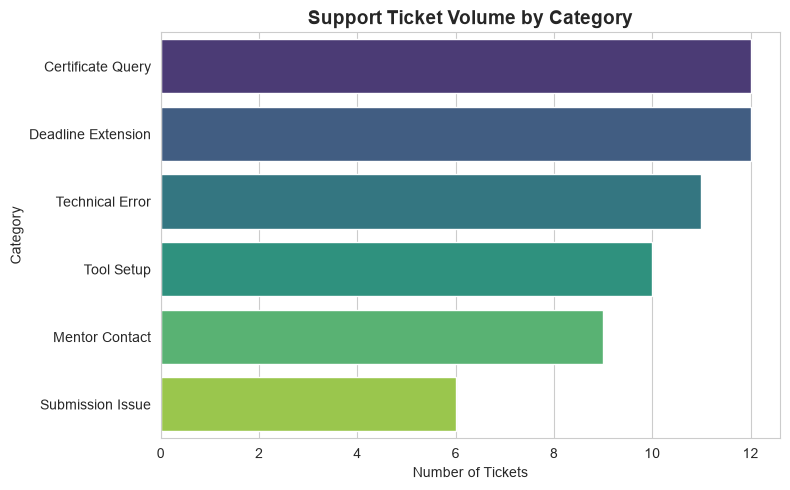

In [9]:
# Ticket category distribution chart 

plt.figure(figsize=(8,5))
sns.countplot(y="category", data=tickets_df, order=tickets_df["category"].value_counts().index, palette="viridis")
plt.title("Support Ticket Volume by Category", fontsize=14, fontweight="bold")
plt.xlabel("Number of Tickets")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("ticket_category_distribution.png", dpi=150)
plt.show()

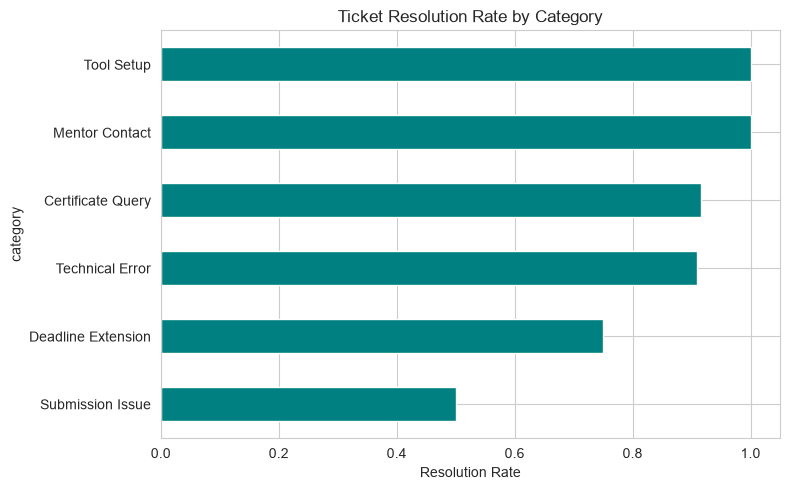

In [10]:
# Resolution rate chart 

resolution_rate = tickets_df.groupby("category")["resolved"].mean().sort_values()

plt.figure(figsize=(8,5))
resolution_rate.plot(kind="barh", color="teal")
plt.title("Ticket Resolution Rate by Category")
plt.xlabel("Resolution Rate")
plt.tight_layout()
plt.savefig("resolution_rate.png", dpi=150)
plt.show()

In [11]:
# Save model files for the dashboard 

joblib.dump(vectorizer, "vectorizer.pkl")
joblib.dump(faq_vectors, "faq_vectors.pkl")
faq_df.to_csv("faq_data.csv", index=False)
print("Saved: faq_data.csv, support_tickets.csv, vectorizer.pkl, faq_vectors.pkl, charts")

Saved: faq_data.csv, support_tickets.csv, vectorizer.pkl, faq_vectors.pkl, charts
